Saving captcha zakariya.jpg to captcha zakariya.jpg


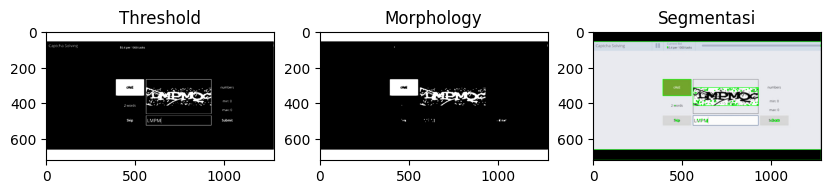

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload gambar CAPTCHA
from google.colab import files
uploaded = files.upload()

# Baca gambar
img = cv2.imread(list(uploaded.keys())[0])

# Convert ke grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Thresholding (binerisasi)
_, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

# Morphology - Opening (hilangkan noise)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Morphology - Closing (rapikan objek)
closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

# Segmentasi (contour)
contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Gambar bounding box
output = img.copy()
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(output, (x,y), (x+w, y+h), (0,255,0), 2)

# Tampilkan hasil
plt.figure(figsize=(10,6))

plt.subplot(1,3,1)
plt.title("Threshold")
plt.imshow(thresh, cmap='gray')

plt.subplot(1,3,2)
plt.title("Morphology")
plt.imshow(closing, cmap='gray')

plt.subplot(1,3,3)
plt.title("Segmentasi")
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

plt.show()